## Data analysis and extraction

In [1]:
import copy
# from comet_ml import Experiment

import os
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import random

from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

In [2]:
# extract the paths to the dataset
DATASETS_PATH = os.path.join('..','..','..','data')
TEST_DATASET_PATH = os.path.join(DATASETS_PATH, 'test.pickle')
TRAIN_DATASET_PATH = os.path.join(DATASETS_PATH, 'train.pickle')

# open datasets with pickle ( resulting object is a pandas.DataFrame )
with open(TEST_DATASET_PATH, 'rb') as f:
    test_dataset = pkl.load(f)

with open(TRAIN_DATASET_PATH, 'rb') as f:
    train_dataset = pkl.load(f)

type(train_dataset) # pandas.core.frame.DataFrame
train_dataset.info() 
test_dataset.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4053 entries, 0 to 4052
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sensor_data           4053 non-null   object 
 1   label                 4053 non-null   int64  
 2   model                 4053 non-null   object 
 3   velocity              4053 non-null   int64  
 4   mass                  4053 non-null   float64
 5   deceleration_average  4053 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 190.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sensor_data           1001 non-null   object 
 1   label                 1001 non-null   int64  
 2   model                 1001 non-null   object 
 3   velocity              1001 non-null   int64  
 4   mass 

/tmp/ipykernel_1450/3460919389.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  test_dataset = pkl.load(f)
/tmp/ipykernel_1450/3460919389.py:11: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case,

In [3]:
# sensor data includes all of our sensor data
sensor_data = test_dataset['sensor_data'] # shape (1001,) i.e. 1001 entries 

# for every dataset we have a numpy array 
first_sensor_data = sensor_data[0] # shape (128, 6) i.e. a matrix, 128 time steps, 6 measurements per time step (time series)

print(sensor_data.shape)
first_sensor_data.shape

(1001,)


(128, 6)

`PyTorch` expects inputs to CNNs in this shape : **(batch_size, channels, height, width)**

In [4]:
class SensorDataSet(Dataset):
    """
    Custom PyTorch Dataset class for loading sensor data from a pandas DataFrame.
    Each row of the DataFrame contains 2 fields : the sensor data and the corresponding label.
    """
    def __init__(self, dataset: pd.DataFrame):
        """
        Initializes the dataset object which is a Pandas Data Frame.
        """
        self.dataset = dataset

    def __getitem__(self, idx):
        """
        Retrieves the sample (returns tuple of data and label) at the specified index given as input.
        """
        data = self.dataset.iloc[idx]
        
        sensor_tensor = torch.tensor(data['sensor_data'], dtype=torch.float32)          
        label_tensor = torch.tensor(data['label'], dtype=torch.int64)
        
        return sensor_tensor, label_tensor

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return len(self.dataset)


In [5]:
batch_size = 64 

# First we create the Data loaders for training and for testing
train_dataloader = DataLoader(SensorDataSet(train_dataset), batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(SensorDataSet(test_dataset), batch_size=batch_size)

# We can fetch one batch from the training data 
train_data, train_labels = next(iter(train_dataloader))

# We can inspect input and label shapes
print('Input shape:', train_data.shape)     # expect (batch_size, 1, 128, 6)
print('Label shape:', train_labels.shape)   # expect (batch_size,)

# And we can also check class distribution
print(train_dataset['label'].value_counts()) # in the training dataset
print(test_dataset['label'].value_counts()) # in the test dataset 

Input shape: torch.Size([64, 128, 6])
Label shape: torch.Size([64])
label
0     1798
6      294
3      286
1      273
7      258
8      253
4      236
2      227
5      225
9       94
10      89
11      20
Name: count, dtype: int64
label
0    593
2    105
1    104
4    103
5     96
Name: count, dtype: int64


We notice from above that the dataset presents some imbalance in the class distribution, especially with class 0 being overrepresented (number of samples is way higher than the other classes) and classes 9, 10, 11 being underrepresented. We may assume this imbalance will somehow hinder the performance of our model.

In [6]:
# Class labels 

FAILURE_CLASSES = [
    ("0-0-0-0", "All brakes intact (no irregularities)."),
    ("0-0-1-0", "Rear Left Brake with irregularity."),
    ("0-0-0-1", "Rear Right Brake with irregularity."),
    ("0-0-1-1", "Both Rear Brakes with irregularities."),
    ("1-0-0-0", "Front Left Brake with irregularity."),
    ("0-1-0-0", "Front Right Brake with irregularity."),
    ("1-1-0-0", "Both Front Brakes with irregularities."),
    ("1-0-1-0", "Left Brakes (Front + Rear Left) with irregularities."),
    ("0-1-0-1", "Right Brakes (Front + Rear Right) with irregularities."),
    ("1-0-0-1", "Front Left and Rear Right Brakes with irregularities."),
    ("0-1-1-0", "Front Right and Rear Left Brakes with irregularities."),
    ("1-1-1-1", "All Brakes with irregularities.")
]

## The 2D CNN model

The aim is to develop a 2D convolutional neural network that will be trained with the deceleration measurement series to classify the vehicle's braking system as either defective or not defective (through the 12 provided classes). It should take the recorded measurement series with the three linear accelerations and the three angular velocities of the deceleration measurement as input. As seen above, we measure 6 values on 128 time steps. As we are working with a CNN in PyTorch, the input is of size (batch_size,1,128,6). The following model simply breaks down into : 

* Two 2D convolutional layers with max pooling for feature extraction.
* Dropout possibility to reduce overfitting, especially with imbalanced data.
* Final dense layer with 12 output units for the 12 classes.


In [7]:
from model import CNNClassifier

We now need to split the training dataset into a training set which constitutes around 80% of the ``train.pickle`` file, and the validation set which constitutes the other 20%.
The random split may be responsible of a model performance that varies between one split and the other, as some parts of the dataset may be harder to train on that others. 

In [8]:
# We can now divise the training data with a random split into 80% for training and 20% for validation

def get_dataloaders(train_dataset_df, batch_size, val_ratio=0.2, seed=42): 
    dataset = SensorDataSet(train_dataset_df.sample(frac=1))  # with a different shuffle everytime

    # Proportions of the training and validation data
    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size

    # Generates a random seed everytime for different splits
    random_seed = random.randint(0, 99999)
    generator = torch.Generator().manual_seed(random_seed)

    # Now we cna use random_split to divise the data
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator) #=torch.Generator().manual_seed(seed))
    
    # And create data loaders that are returned
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader


## Training loop

In [9]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# === Training loop ===

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, split, patience=5): 

    model.to(device)

    # Dictionary to store loss and accuracy history 
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    # start time to assess the total training duration
    start_time = time.time()

    # Early stopping parameters
    best_val_loss = float('inf')
    counter = 0
    best_model_weights = None
    
    for epoch in range(num_epochs):

        # --- Training step ---
        model.train()
        running_loss = 0.0
        all_preds, all_labels = [], []

        for inputs, labels in train_loader: 
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            optimizer.zero_grad() # Clear gradients from previous step
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step() # Update model params

            # Predictions and labels for accuracy computation
            running_loss += loss.item()
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        # Average training loss and accuracy for the epoch
        train_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(all_labels, all_preds)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        if split: # If the random split is done
            # --- Validation step ---
            model.eval()
            val_loss = 0.0
            val_preds, val_labels = [], []

            with torch.no_grad(): # disables gradient computation for validation
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()
                    val_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())

            # Average validation loss and accuracy for the epoch
            val_loss /= len(val_loader)
            val_acc = accuracy_score(val_labels, val_preds)

            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            # Display progress 
            print(f"Epoch {epoch+1}/{num_epochs} - "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}"
                f" | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
            
            # --- Early stopping ---
            if val_loss < best_val_loss: # If validation improves, reset counter and save weights
                best_val_loss = val_loss
                counter = 0
                best_model_weights = copy.deepcopy(model.state_dict())  # Save best model
            else: # Otherwise, increase early stopping counter
                counter += 1
                if counter >= patience: # patience = number of epochs waited before stopping
                    print(f"Early stopping at epoch {epoch+1}")
                    break
        else: 
            # Display progress for training
            print(f"Epoch {epoch+1}/{num_epochs} - "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

    # Restore best model weights after training is over
    if best_model_weights:
        model.load_state_dict(best_model_weights)
        
    # Calculate total training time
    elapsed = time.time() - start_time
    print(f"Training completed in {(elapsed):.2f} seconds")

    return model, history, elapsed


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dropout_rate = 0.3
model = CNNClassifier(dropout_rate=dropout_rate).to(device)

# Handling class imbalance by computing weights inversely proportional to class frequencies
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_dataset['label']),
    y=train_dataset['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float, device=device)

# Weighted loss function
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor) 

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# --- Training --- 
trained_model, history, elapsed = train_model(model, 
                                            train_dataloader, # Whole training file 
                                            test_dataloader, # Whole test file
                                            criterion, 
                                            optimizer, 
                                            num_epochs=5, 
                                            device=device,
                                            split=False
                                        )

/root/.venv/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


Epoch 1/5 - Train Loss: 1.6964, Train Acc: 0.3358
Epoch 2/5 - Train Loss: 0.3958, Train Acc: 0.8058
Epoch 3/5 - Train Loss: 0.2289, Train Acc: 0.9092
Epoch 4/5 - Train Loss: 0.1527, Train Acc: 0.9410
Epoch 5/5 - Train Loss: 0.1123, Train Acc: 0.9544
Training completed in 1.43 seconds


## Validation loop

In [11]:
# === Validation loop ===

def evaluate_model(model, test_loader, device, class_names=None, plot=True):
    model.eval()
    model.to(device)
    
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1) # Class with highest score
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Ensure all classes are represented in evaluation (both true and predicted)
    unique_classes = sorted(np.unique(np.concatenate([all_preds, all_labels])))

    # Generate class names dynamically (class indices as labels) if not provided
    if class_names is None:
        class_names = [str(i) for i in unique_classes]

    # Overall accuracy
    accuracy = accuracy_score(all_labels, all_preds)
    
    print(f"\nTest Accuracy: {accuracy:.4f}\n")
    
    # Optional: Detailed performance diagnostics, 

    # Classification Report : precision, recall, F1-score for each class

    
    # Confusion Matrix
    
    cm = confusion_matrix(all_labels, all_preds)
    if plot:
        print("Classification Report:")
        print(classification_report(all_labels, all_preds, digits=4, target_names=class_names))
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("Confusion Matrix")
        plt.show()

    return accuracy



Test Accuracy: 0.1978

Classification Report:
              precision    recall  f1-score   support

           0     0.8688    0.2344    0.3692       593
           1     1.0000    0.1346    0.2373       104
           2     0.3333    0.0286    0.0526       105
           3     0.0000    0.0000    0.0000         0
           4     0.1296    0.3398    0.1877       103
           5     1.0000    0.0729    0.1359        96
           6     0.0000    0.0000    0.0000         0
           7     0.0000    0.0000    0.0000         0
           8     0.0000    0.0000    0.0000         0
           9     0.0000    0.0000    0.0000         0

    accuracy                         0.1978      1001
   macro avg     0.3332    0.0810    0.0983      1001
weighted avg     0.7628    0.1978    0.2812      1001



/root/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


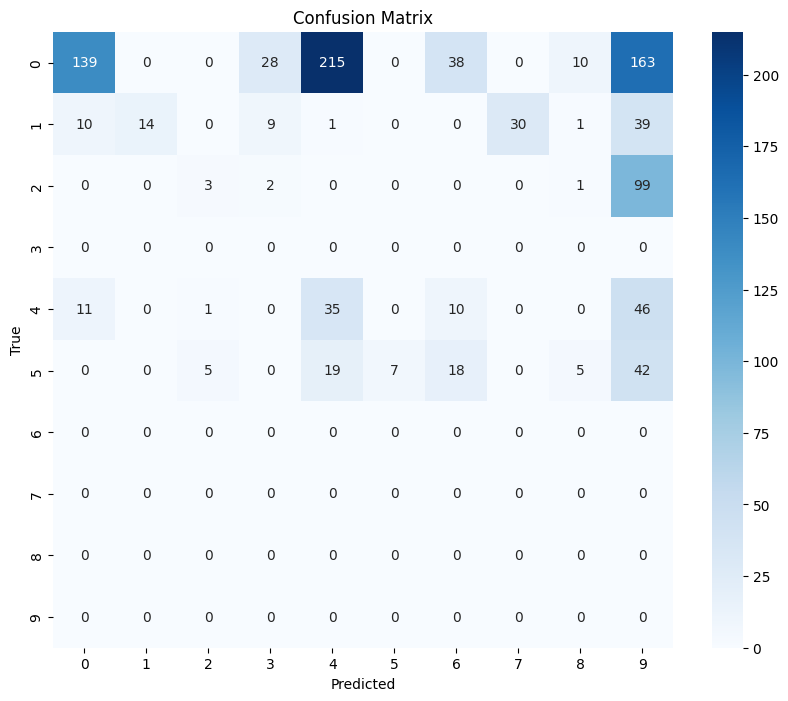

In [12]:
# Evaluate the trained model on the test dataset
test_acc = evaluate_model(trained_model, test_dataloader, device=device)


dropout_str = (
    f"dropout{int(model.dropout_rate * 100)}" if model.dropout_rate > 0 else "nodropout"
)

# Descriptive filename with necessary hyperparameters to identify the model
filename = (
    f"model_opt-{optimizer.__class__.__name__}"
    f"_lr-{optimizer.param_groups[0]['lr']}"
    f"_loss-{criterion.__class__.__name__}"
    f"_{dropout_str}"
    f"_acc-{test_acc:.4f}.pth"
)

save_path = os.path.join("saved_models", filename)
# os.makedirs("saved_models", exist_ok=True)

# Save the model's trained weights (.pth file)
# torch.save(model.state_dict(), save_path)
# print(f"Model saved: {filename}")


## Experiment to evaluate the impact of the choice of hyperparameters on the performance of the model

In [13]:
def run_experiment(config, train_loader, val_loader, test_loader, train_dataset, input_model_class, device, project_name="dl-seminar-v2", workspace="mmrini"):
    # Start Comet experiment
    experiment = Experiment( # If needed, the parameters are to be determined
        api_key="",  
        project_name="",
        workspace="",
        auto_output_logging="simple"
    )

    experiment.set_name(f"lr={config['lr']}, batch={config['batch_size']}, dropout={config['dropout']}, opt={config['optimizer']}")
    experiment.log_parameters(config)

    # Model with config-specified dropout
    model = input_model_class(dropout_rate=config['dropout']).to(device)

    # Class weights to handle imbalance
    class_weights = compute_class_weight(class_weight='balanced',
                                         classes=np.unique(train_dataset['label']),
                                         y=train_dataset['label'].values)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # Optimizer selection
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'])
    elif config['optimizer'] == 'AdamW':
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'])
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")

    # Train model
    model, history, elapsed = train_model(
        model, train_loader, val_loader,
        criterion, optimizer,
        num_epochs=config.get('epochs', 20),
        device=device,
        split=True
    )

    # Evaluate and log accuracy
    test_acc = evaluate_model(model, test_loader, device=device)
    experiment.log_metric("test_accuracy", test_acc)

    experiment.end()
    return test_acc, history, elapsed

In [14]:
from itertools import product

# Value ranges for each hyperparameter
lr_list = [0.0001, 0.0005, 0.001, 0.005] 
batch_size_list = [16, 32, 64]   
dropout_list = [0.0, 0.3, 0.5]
optimizer_list = ['Adam', 'SGD', 'AdamW']

# This calculates all the possible combinations
configs = [
    {"lr": lr, "batch_size": bs, "dropout": dr, "optimizer": opt}
    for lr, bs, dr, opt in product(lr_list, batch_size_list, dropout_list, optimizer_list)
]


In [15]:
run_exp = False # turn into true if running the experiments is needed

if run_exp:
    results = []

    # Loop for the big experiment 

    for i, config in enumerate(configs):
        print(f"\n=== Running Config {i+1}/{len(configs)} ===")
        
        # Build Data loaders for this batch size

        train_loader, val_loader = get_dataloaders(train_dataset, batch_size=config['batch_size'], val_ratio=0.2)
        test_loader = DataLoader(SensorDataSet(test_dataset), batch_size=config['batch_size'])  

        # Run experiment and collect results
        acc, history, duration = run_experiment(
            config=config,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            train_dataset=train_dataset,
            input_model_class=CNNClassifier,  
            device=device
        )

        config_result = config.copy()
        config_result["test_accuracy"] = acc
        config_result["train_time_sec"] = duration
        results.append(config_result)

## Evaluation of the real performance of the model using random splitting 

In [16]:
# Loop of 10 trainings over 10 different random splits 

mean_test_acc_list = [] # Stores mean test accuracy for each random split

for i in range (10): # 10 random splits on the training dataset
    batch_size = 64 
    train_loader, val_loader = get_dataloaders(train_dataset, batch_size=batch_size, val_ratio=0.2) # here occurs the random split on each iteration

    test_acc_list = []

    for j in range (10): # 10 training runs on each random split
        
        # === New model and optimizer re-initialized for each training run ===
        dropout_rate = 0.3
        model = CNNClassifier(dropout_rate=dropout_rate).to(device)

        # Re-initialize optimizer and criterion with current model
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

        # Training
        trained_model, history, elapsed = train_model(model, 
                                                    train_loader, 
                                                    val_loader,
                                                    criterion, 
                                                    optimizer, 
                                                    num_epochs=5, 
                                                    device=device,
                                                    split=True
                                                )
        
        # Validation
        test_acc = evaluate_model(trained_model, test_dataloader, device=device, plot=False)
        test_acc_list.append(test_acc)

    mean_test_acc_list.append(np.mean(test_acc_list))

# Final overall mean test accuracy across all splits and runs
print(f"Overall mean test accuracy : {np.mean(mean_test_acc_list)}")

Epoch 1/5 - Train Loss: 1.9248, Train Acc: 0.2741 | Val Loss: 0.8225, Val Acc: 0.7815
Epoch 2/5 - Train Loss: 0.4981, Train Acc: 0.7724 | Val Loss: 0.2491, Val Acc: 0.9099
Epoch 3/5 - Train Loss: 0.2165, Train Acc: 0.9155 | Val Loss: 0.1422, Val Acc: 0.9654
Epoch 4/5 - Train Loss: 0.1518, Train Acc: 0.9340 | Val Loss: 0.0989, Val Acc: 0.9802
Epoch 5/5 - Train Loss: 0.1101, Train Acc: 0.9568 | Val Loss: 0.1037, Val Acc: 0.9815
Training completed in 0.97 seconds

Test Accuracy: 0.4106

Epoch 1/5 - Train Loss: 1.7114, Train Acc: 0.3679 | Val Loss: 0.7157, Val Acc: 0.6235
Epoch 2/5 - Train Loss: 0.4404, Train Acc: 0.8073 | Val Loss: 0.2291, Val Acc: 0.9617
Epoch 3/5 - Train Loss: 0.2143, Train Acc: 0.9097 | Val Loss: 0.1448, Val Acc: 0.9642
Epoch 4/5 - Train Loss: 0.1380, Train Acc: 0.9402 | Val Loss: 0.1047, Val Acc: 0.9753
Epoch 5/5 - Train Loss: 0.0945, Train Acc: 0.9615 | Val Loss: 0.1310, Val Acc: 0.9827
Training completed in 0.98 seconds

Test Accuracy: 0.2777

Epoch 1/5 - Train Loss

KeyboardInterrupt: 

In [ ]:
training_runs = list(range(1, len(mean_test_acc_list) + 1))

# Plot of the mean accuracies over each 10 training across each of the 10 random splits

plt.figure(figsize=(8, 5))
plt.plot(training_runs, mean_test_acc_list, marker='o', linestyle='-')
plt.title('Mean test accuracy resulting from 10 trainings across each of 10 random splits')
plt.xlabel('Random splits')
plt.ylabel('Mean test accuracy')
plt.xticks(training_runs)
plt.grid(True)
plt.tight_layout()
plt.show()